# GAT Session Recommendation Results Presentation

This notebook presents the GAT-based session recommendation experiments as a results story:

1. Compare the **best achieved trained results** against the matching published or contextual baseline.
2. Explain how each direct model evolved across result iterations.
3. Present **GAT-SAGPool** as the third architecture, separately from the controlled SR-GNN/TAGNN readout comparisons.
4. Keep pending work explicit, especially fourth-iteration `GAT-TAGNN`.

## Executive Summary

- **GAT-SR-GNN** best Yoochoose run is `results-1`: MRR@20 31.146 (+0.206 vs SR-GNN) and Precision@20 70.124 (-0.446).
- **GAT-SR-GNN** best Diginetica run is `results-3`: Precision@20 50.736 (+0.006 vs SR-GNN), with MRR@20 -0.735 below SR-GNN.
- **GAT-TAGNN** best runs are still from `results-1`: Yoochoose MRR@20 is -0.116 vs TAGNN and Diginetica MRR@20 is -0.677 vs TAGNN.
- **GAT-SAGPool** adds a third architecture: Yoochoose Precision@20 70.185 and MRR@20 30.882; Diginetica Precision@20 50.427 and MRR@20 16.743. These are contextual comparisons because SAGPool changes the readout family.
- Fourth-iteration TAGNN is not claimed yet because that model has not been trained for `results-4`.

## Result Iterations

| Iteration | Folder | GAT-SR-GNN status | GAT-TAGNN status | What Changed |
| --- | --- | --- | --- | --- |
| 1 | results-1 | trained | trained | Initial complete GAT-SR-GNN and GAT-TAGNN archive used as the first working reference point. |
| 2 | results-2 | trained | pending | Simplified GAT stack revision; only GAT-SR-GNN was rerun in this export. |
| 3 | results-3 | trained | trained | GATv2/performance iteration, including TAGNN scoring/chunking changes and SR-GNN positional-embedding rollback. |
| 4 | results-4 | trained | pending | Repeated transition edges plus explicit residual connections in the GAT stack; TAGNN still pending. |

`GAT-SAGPool` is stored separately in `results-gat-sagpool/` because it is a different readout architecture rather than another iteration of the SR-GNN/TAGNN readout branches.

## Aktualne Schematy Architektur

Wspólne wejście grafowe: każdy prefiks sesji jest zamieniany na skierowany graf przejść między itemami, z osobnymi indeksami krawędzi forward i backward. Oba modele używają `hidden_dim=100`, embeddingu itemów z `padding_idx=0`, `GATv2Conv`, `4` attention heads (`25` wymiarów/head), `ELU`, dropout `0.1`, self-loops oraz jawnych residual updates w każdym kierunkowym stosie GAT.

**GAT-SR-GNN (aktualny, iteracja 4)**

```text
Graf prefiksu sesji
  -> item embedding: item_id -> 100
  -> bidirectional GATv2 encoder
       forward stack: 1 layer, 4 heads x 25 dims -> 100
       backward stack: 1 layer, 4 heads x 25 dims -> 100
  -> direction fusion: concat(100 + 100) -> linear 200 -> 100
  -> mapowanie node embeddings z powrotem do kolejności prefiksu
  -> SR-GNN readout
       local preference: embedding ostatniego kliknięcia
       global preference: attention po node'ach prefiksu warunkowana ostatnim kliknięciem
  -> hybrid projection: concat(local 100 + global 100) -> 100
  -> wyniki dot-product względem embeddingów wszystkich itemów
```

**GAT-TAGNN (aktualny stan kodu, iteracja 4 czeka na uruchomienie)**

```text
Graf prefiksu sesji
  -> item embedding: item_id -> 100
  -> bidirectional GATv2 encoder
       forward stack: 2 layers, 4 heads x 25 dims -> 100 per layer
       backward stack: 2 layers, 4 heads x 25 dims -> 100 per layer
  -> direction fusion: concat(100 + 100) -> linear 200 -> 100
  -> padding node embeddings w kolejności prefiksu + sequence mask
  -> base session preference
       global attention warunkowana ostatnim kliknięciem
       linear transform concat(global 100 + last-click 100) -> 100
  -> target-aware candidate scoring
       candidate chunks: 32768 itemów
       target attention: candidate embedding x przetransformowane node'y prefiksu
       final score: base dot-product + target-aware score
```

## Architecture Evolution Logic (Iterations 1 -> 4)

| Iteration | Main change | Why | Effect on architecture |
| --- | --- | --- | --- |
| 1  | Baseline GAT notebooks with architecture docs (`GATConv`, weighted edges, explicit residual) | First complete working GAT replacement for SR-GNN/TAGNN pipelines | Established the initial bidirectional-GAT + original readout structure |
| 2  | Simplification pass: removed edge-weight path and manual residual in stack; kept native attention/self-loops | Reduce optimization friction and let attention learn edge importance directly | Cleaner encoder block and simpler message-passing interface |
| 3  | Performance pass: moved to `GATv2Conv`; SR removed positional embedding path; TAGNN scoring/chunking updated | Improve attention expressiveness and scoring efficiency | Stronger encoder variant and revised TAGNN scoring path |
| 4 (current) | Reintroduced explicit residual update and kept repeated transitions in graph construction (`0a15170`) | Preserve transition frequency signal and stabilize deep feature updates | Current code state combines GATv2 + residual updates + repeated-transition edges |

Cause -> effect chain: simplify unstable parts (iter 2) -> upgrade expressive power and scoring efficiency (iter 3) -> re-add controlled inductive bias from transition repetition plus residual stabilization (iter 4).

## Best Achieved Architecture Results vs Baselines

The main comparison selects the best trained run for each architecture and dataset by `MRR@20`, using `Precision@20` as a tie-breaker. `GAT-SR-GNN` is compared with published **SR-GNN**, `GAT-TAGNN` with published **TAGNN**, and `GAT-SAGPool` is shown against the published **SR-GNN** row as graph-session context rather than a strict readout-controlled baseline.

| Architecture | Dataset | Best Run | Baseline | Comparison Type | Precision@20 | Baseline P@20 | Delta P@20 | MRR@20 | Baseline MRR@20 | Delta MRR@20 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| GAT-SAGPool | Diginetica | results-gat-sagpool | SR-GNN | contextual graph-session baseline; SAGPool is a different readout | 50.427 | 50.730 | -0.303 | 16.743 | 17.590 | -0.847 |
| GAT-SAGPool | Yoochoose 1/64 | results-gat-sagpool | SR-GNN | contextual graph-session baseline; SAGPool is a different readout | 70.185 | 70.570 | -0.385 | 30.882 | 30.940 | -0.058 |
| GAT-SR-GNN | Diginetica | results-3 | SR-GNN | direct SR-GNN readout comparison | 50.736 | 50.730 | 0.006 | 16.855 | 17.590 | -0.735 |
| GAT-SR-GNN | Yoochoose 1/64 | results-1 | SR-GNN | direct SR-GNN readout comparison | 70.124 | 70.570 | -0.446 | 31.146 | 30.940 | 0.206 |
| GAT-TAGNN | Diginetica | results-1 | TAGNN | direct TAGNN readout comparison | 51.252 | 51.310 | -0.058 | 17.353 | 18.030 | -0.677 |
| GAT-TAGNN | Yoochoose 1/64 | results-1 | TAGNN | direct TAGNN readout comparison | 70.611 | 71.020 | -0.409 | 31.004 | 31.120 | -0.116 |

![Best GAT architecture results compared with baselines](results-analysis/best_vs_baseline.png)

![Best-result deltas from the matching baseline](results-analysis/best_delta_vs_baseline.png)

![Best direct comparison across GAT architectures](results-analysis/architecture_best_comparison.png)

## Model Evolution: GAT-SR-GNN

`GAT-SR-GNN` has a complete four-iteration trace. The first archive remains strongest on Yoochoose, while Diginetica peaks in the third iteration. The fourth iteration is still useful evidence: it tests repeated transition edges plus explicit residual connections, but it does not improve final test metrics over the best previous run.

| Dataset | Run | Status | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- | --- | --- |
| Diginetica | results-1 | trained | 50.250 | 16.646 | 4 | 19.413 |
| Diginetica | results-2 | trained | 50.629 | 16.725 | 28 | 19.486 |
| Diginetica | results-3 | trained | 50.736 | 16.855 | 19 | 19.563 |
| Diginetica | results-4 | trained | 50.454 | 16.802 | 19 | 19.529 |
| Yoochoose 1/64 | results-1 | trained | 70.124 | 31.146 | 9 | 32.706 |
| Yoochoose 1/64 | results-2 | trained | 68.729 | 30.355 | 29 | 31.680 |
| Yoochoose 1/64 | results-3 | trained | 68.942 | 30.563 | 25 | 31.759 |
| Yoochoose 1/64 | results-4 | trained | 68.754 | 30.595 | 27 | 31.767 |

![GAT-SR-GNN metric evolution](results-analysis/gat_sr_gnn_evolution.png)

## Model Evolution: GAT-TAGNN

`GAT-TAGNN` has trained exports for iterations 1 and 3. Iterations 2 and 4 remain pending, so the notebook does not make claims for those runs.

| Dataset | Run | Status | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- | --- | --- |
| Diginetica | results-1 | trained | 51.252 | 17.353 | 4 | 19.651 |
| Diginetica | results-2 | pending |  |  |  |  |
| Diginetica | results-3 | trained | 50.925 | 17.128 | 25 | 19.505 |
| Diginetica | results-4 | pending |  |  |  |  |
| Yoochoose 1/64 | results-1 | trained | 70.611 | 31.004 | 10 | 32.669 |
| Yoochoose 1/64 | results-2 | pending |  |  |  |  |
| Yoochoose 1/64 | results-3 | trained | 68.591 | 29.892 | 30 | 31.336 |
| Yoochoose 1/64 | results-4 | pending |  |  |  |  |

![GAT-TAGNN metric evolution](results-analysis/gat_tagnn_evolution.png)

## Third Architecture: GAT-SAGPool

`GAT-SAGPool` replaces the SR-GNN/TAGNN session readout with self-attention graph pooling. This makes it a third architecture rather than an iteration of either direct branch. It is reported with the same metrics and dataset protocol, but its comparison to SR-GNN is contextual because both encoder and readout family differ.

| Dataset | Run | Precision@20 | MRR@20 | Best Epoch | Best Val MRR@20 |
| --- | --- | --- | --- | --- | --- |
| Diginetica | results-gat-sagpool | 50.427 | 16.743 | 4 | 19.490 |
| Yoochoose 1/64 | results-gat-sagpool | 70.185 | 30.882 | 7 | 32.571 |

![GAT-SAGPool baseline context](results-analysis/gat_sagpool_baseline_context.png)

![GAT-SAGPool compared with the other GAT architectures](results-analysis/gat_sagpool_vs_architectures.png)

![GAT-SAGPool delta against the other GAT architectures](results-analysis/gat_sagpool_delta_vs_architectures.png)

![GAT-SAGPool validation MRR compared with the other architectures](results-analysis/gat_sagpool_validation_vs_architectures.png)

## Validation Curves

The validation curves are supporting diagnostics for the exported checkpoints. The main comparison remains the held-out test `Precision@20` and `MRR@20` above.

![GAT-SR-GNN validation history](results-analysis/gat_sr_gnn_validation_history.png)

![GAT-TAGNN validation history](results-analysis/gat_tagnn_validation_history.png)

![GAT-SAGPool validation history](results-analysis/gat_sagpool_validation_history.png)

## Reproducibility: Build Tables and Plots

The cells below rebuild every table and figure used above directly from the archived result folders. Running them updates the derived files under `results-analysis/`, including the main best-vs-baseline plots, the direct architecture comparison, the per-model evolution plots, and the SAGPool plots.

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
PRESENTATION_DIR = PROJECT_ROOT / "results-analysis"
PRESENTATION_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format

BASELINE_ROWS = [
    ("POP", 6.71, 1.65, 0.89, 0.20),
    ("S-POP", 30.44, 18.35, 21.06, 13.68),
    ("Item-KNN", 51.60, 21.81, 35.75, 11.57),
    ("BPR-MF", 31.31, 12.08, 5.24, 1.98),
    ("FPMC", 45.62, 15.01, 26.53, 6.95),
    ("GRU4REC", 60.64, 22.89, 29.45, 8.33),
    ("NARM", 68.32, 28.63, 49.70, 16.17),
    ("STAMP", 68.74, 29.67, 45.64, 14.32),
    ("SR-GNN", 70.57, 30.94, 50.73, 17.59),
    ("TAGNN", 71.02, 31.12, 51.31, 18.03),
]
BASELINE_COLUMNS = [
    "method", "yoochoose_1_64_precision@20", "yoochoose_1_64_mrr@20",
    "diginetica_precision@20", "diginetica_mrr@20",
]
baselines = pd.DataFrame(BASELINE_ROWS, columns=BASELINE_COLUMNS)

ITERATIONS = [
    {"iteration": 1, "folder": "results-1", "GAT-SR-GNN status": "trained", "GAT-TAGNN status": "trained", "What Changed": "Initial complete GAT-SR-GNN and GAT-TAGNN archive used as the first working reference point."},
    {"iteration": 2, "folder": "results-2", "GAT-SR-GNN status": "trained", "GAT-TAGNN status": "pending", "What Changed": "Simplified GAT stack revision; only GAT-SR-GNN was rerun in this export."},
    {"iteration": 3, "folder": "results-3", "GAT-SR-GNN status": "trained", "GAT-TAGNN status": "trained", "What Changed": "GATv2/performance iteration, including TAGNN scoring/chunking changes and SR-GNN positional-embedding rollback."},
    {"iteration": 4, "folder": "results-4", "GAT-SR-GNN status": "trained", "GAT-TAGNN status": "pending", "What Changed": "Repeated transition edges plus explicit residual connections in the GAT stack; TAGNN still pending."},
]
iteration_status = pd.DataFrame(ITERATIONS)
iteration_status.to_csv(PRESENTATION_DIR / "iteration_status.csv", index=False)

REFERENCE_BY_MODEL = {"GAT-SR-GNN": "SR-GNN", "GAT-TAGNN": "TAGNN", "GAT-SAGPool": "SR-GNN"}
COMPARISON_NOTE = {
    "GAT-SR-GNN": "direct SR-GNN readout comparison",
    "GAT-TAGNN": "direct TAGNN readout comparison",
    "GAT-SAGPool": "contextual graph-session baseline; SAGPool is a different readout",
}
DATASET_KEY = {"Yoochoose 1/64": "yoochoose_1_64", "Diginetica": "diginetica"}
EXPECTED_RESULT_COLUMNS = [
    "model", "iteration", "folder", "dataset", "test_precision@20", "test_mrr@20", "test_loss",
    "best_epoch", "best_validation_precision@20", "best_validation_mrr@20", "train_examples",
    "validation_examples", "test_examples", "num_items", "checkpoint_path",
]
iteration_status

,iteration,folder,GAT-SR-GNN status,GAT-TAGNN status,What Changed
0,1,results-1,trained,trained,Initial complete GAT-SR-GNN and GAT-TAGNN arch...
1,2,results-2,trained,pending,Simplified GAT stack revision; only GAT-SR-GNN...
2,3,results-3,trained,trained,"GATv2/performance iteration, including TAGNN s..."
3,4,results-4,trained,pending,Repeated transition edges plus explicit residu...


In [36]:
def load_result_file(path, model, iteration, folder):
    if not path.is_file():
        return None
    df = pd.read_csv(path).assign(model=model, iteration=iteration, folder=folder)
    for column in EXPECTED_RESULT_COLUMNS:
        if column not in df.columns:
            df[column] = pd.NA
    return df[EXPECTED_RESULT_COLUMNS]

run_frames = []
for run in ITERATIONS:
    folder = PROJECT_ROOT / run["folder"]
    for filename, model in [
        ("gat_sr_gnn_results.csv", "GAT-SR-GNN"),
        ("gat_tagnn_results.csv", "GAT-TAGNN"),
    ]:
        loaded = load_result_file(folder / filename, model, run["iteration"], run["folder"])
        if loaded is not None:
            run_frames.append(loaded)

sagpool_results = load_result_file(
    PROJECT_ROOT / "results-gat-sagpool" / "gat_sagpool_results.csv",
    "GAT-SAGPool",
    1,
    "results-gat-sagpool",
)
if sagpool_results is not None:
    run_frames.append(sagpool_results)

all_runs = (
    pd.concat(run_frames, ignore_index=True)
    .sort_values(["model", "dataset", "iteration"])
    .reset_index(drop=True)
)
all_runs.to_csv(PRESENTATION_DIR / "all_model_runs.csv", index=False)
all_runs

,model,iteration,folder,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path
0,GAT-SAGPool,1,results-gat-sagpool,Diginetica,50.427,16.743,5.531,4,55.464,19.490,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sagpoo...
1,GAT-SAGPool,1,results-gat-sagpool,Yoochoose 1/64,70.185,30.882,4.337,7,69.306,32.571,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sagpoo...
2,GAT-SR-GNN,1,results-1,Diginetica,50.250,16.646,5.553,4,55.795,19.413,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
3,GAT-SR-GNN,2,results-2,Diginetica,50.629,16.725,5.657,28,55.207,19.486,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
4,GAT-SR-GNN,3,results-3,Diginetica,50.736,16.855,5.654,19,55.478,19.563,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
5,GAT-SR-GNN,4,results-4,Diginetica,50.454,16.802,5.664,19,55.243,19.529,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...
6,GAT-SR-GNN,1,results-1,Yoochoose 1/64,70.124,31.146,4.342,9,69.474,32.706,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
7,GAT-SR-GNN,2,results-2,Yoochoose 1/64,68.729,30.355,4.455,29,66.873,31.680,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
8,GAT-SR-GNN,3,results-3,Yoochoose 1/64,68.942,30.563,4.451,25,66.903,31.759,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...
9,GAT-SR-GNN,4,results-4,Yoochoose 1/64,68.754,30.595,4.455,27,66.754,31.767,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...


In [37]:
best_rows = []
for (model, dataset), group in all_runs.groupby(["model", "dataset"], sort=False):
    best = group.sort_values(
        ["test_mrr@20", "test_precision@20", "iteration"],
        ascending=[False, False, False],
    ).iloc[0]
    reference_method = REFERENCE_BY_MODEL[model]
    dataset_key = DATASET_KEY[dataset]
    reference_precision = baselines.loc[
        baselines["method"] == reference_method,
        f"{dataset_key}_precision@20",
    ].iloc[0]
    reference_mrr = baselines.loc[
        baselines["method"] == reference_method,
        f"{dataset_key}_mrr@20",
    ].iloc[0]
    best_rows.append({
        "model": model,
        "dataset": dataset,
        "best_iteration": int(best["iteration"]),
        "folder": best["folder"],
        "reference_method": reference_method,
        "comparison_note": COMPARISON_NOTE[model],
        "test_precision@20": best["test_precision@20"],
        "reference_precision@20": reference_precision,
        "delta_precision@20": best["test_precision@20"] - reference_precision,
        "test_mrr@20": best["test_mrr@20"],
        "reference_mrr@20": reference_mrr,
        "delta_mrr@20": best["test_mrr@20"] - reference_mrr,
        "best_epoch": best["best_epoch"],
        "best_validation_mrr@20": best["best_validation_mrr@20"],
    })

best_vs_baseline = (
    pd.DataFrame(best_rows)
    .sort_values(["model", "dataset"])
    .reset_index(drop=True)
)
best_vs_baseline.to_csv(PRESENTATION_DIR / "best_vs_baseline.csv", index=False)

gat_sagpool_architecture_results = all_runs[all_runs["model"] == "GAT-SAGPool"].copy()
gat_sagpool_architecture_results.to_csv(PRESENTATION_DIR / "gat_sagpool_architecture_results.csv", index=False)
best_vs_baseline

,model,dataset,best_iteration,folder,reference_method,comparison_note,test_precision@20,reference_precision@20,delta_precision@20,test_mrr@20,reference_mrr@20,delta_mrr@20,best_epoch,best_validation_mrr@20
0,GAT-SAGPool,Diginetica,1,results-gat-sagpool,SR-GNN,contextual graph-session baseline; SAGPool is ...,50.427,50.730,-0.303,16.743,17.590,-0.847,4,19.490
1,GAT-SAGPool,Yoochoose 1/64,1,results-gat-sagpool,SR-GNN,contextual graph-session baseline; SAGPool is ...,70.185,70.570,-0.385,30.882,30.940,-0.058,7,32.571
2,GAT-SR-GNN,Diginetica,3,results-3,SR-GNN,direct SR-GNN readout comparison,50.736,50.730,0.006,16.855,17.590,-0.735,19,19.563
3,GAT-SR-GNN,Yoochoose 1/64,1,results-1,SR-GNN,direct SR-GNN readout comparison,70.124,70.570,-0.446,31.146,30.940,0.206,9,32.706
4,GAT-TAGNN,Diginetica,1,results-1,TAGNN,direct TAGNN readout comparison,51.252,51.310,-0.058,17.353,18.030,-0.677,4,19.651
5,GAT-TAGNN,Yoochoose 1/64,1,results-1,TAGNN,direct TAGNN readout comparison,70.611,71.020,-0.409,31.004,31.120,-0.116,10,32.669


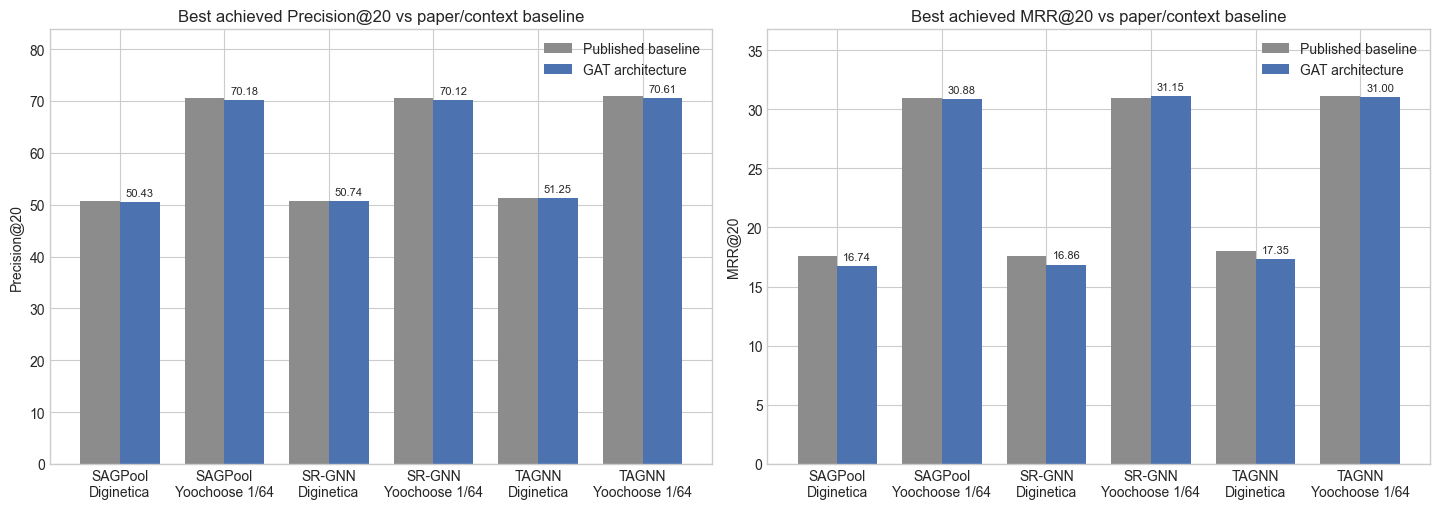

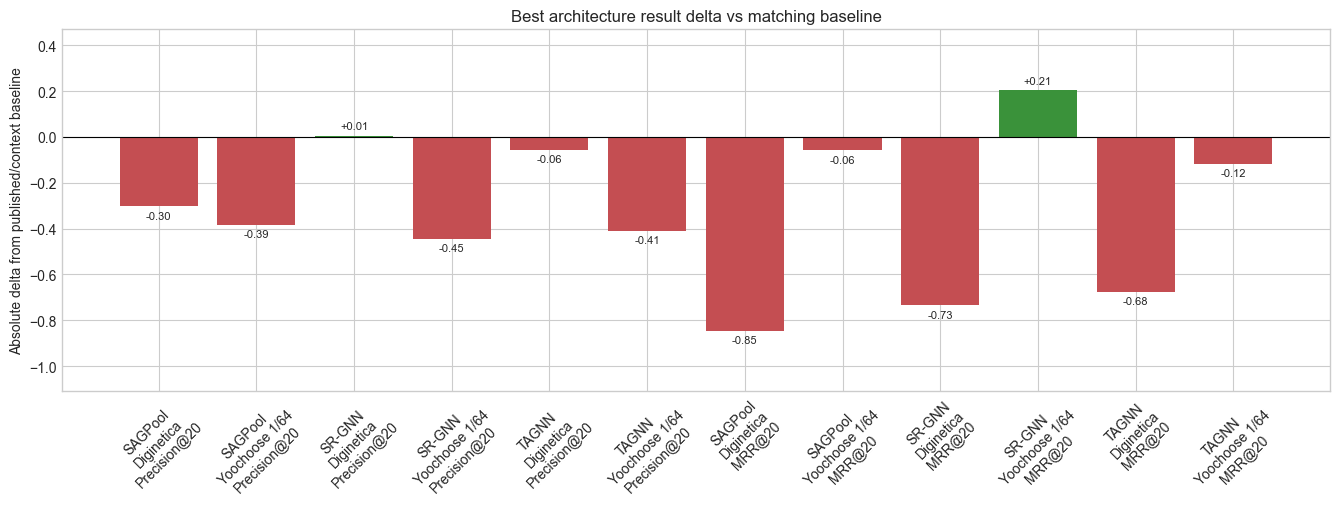

In [38]:
plot_best = best_vs_baseline.copy()
plot_best["label"] = (
    plot_best["model"].str.replace("GAT-", "", regex=False)
    + "\n"
    + plot_best["dataset"]
)
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
for ax, metric, reference_metric, ylabel, title in [
    (axes[0], "test_precision@20", "reference_precision@20", "Precision@20", "Best achieved Precision@20 vs paper/context baseline"),
    (axes[1], "test_mrr@20", "reference_mrr@20", "MRR@20", "Best achieved MRR@20 vs paper/context baseline"),
]:
    x_positions = list(range(len(plot_best)))
    width = 0.38
    ax.bar([x - width / 2 for x in x_positions], plot_best[reference_metric], width=width, label="Published baseline", color="#8c8c8c")
    bars = ax.bar([x + width / 2 for x in x_positions], plot_best[metric], width=width, label="GAT architecture", color="#4c72b0")
    ax.set_xticks(x_positions, plot_best["label"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.18)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "best_vs_baseline.png", dpi=180, bbox_inches="tight")
plt.show()

# Delta from the relevant baseline for each architecture/dataset pair.
delta_plot = best_vs_baseline.melt(
    id_vars=["model", "dataset", "best_iteration"],
    value_vars=["delta_precision@20", "delta_mrr@20"],
    var_name="metric",
    value_name="delta",
)
delta_plot["metric"] = delta_plot["metric"].map({"delta_precision@20": "Precision@20", "delta_mrr@20": "MRR@20"})
delta_plot["label"] = (
    delta_plot["model"].str.replace("GAT-", "", regex=False)
    + "\n"
    + delta_plot["dataset"]
    + "\n"
    + delta_plot["metric"]
)
fig, ax = plt.subplots(figsize=(13.5, 5.2))
bars = ax.bar(
    delta_plot["label"],
    delta_plot["delta"],
    color=["#3a923a" if value >= 0 else "#c44e52" for value in delta_plot["delta"]],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Absolute delta from published/context baseline")
ax.set_title("Best architecture result delta vs matching baseline")
ax.tick_params(axis="x", rotation=45)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
ax.margins(y=0.25)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "best_delta_vs_baseline.png", dpi=180, bbox_inches="tight")
plt.show()

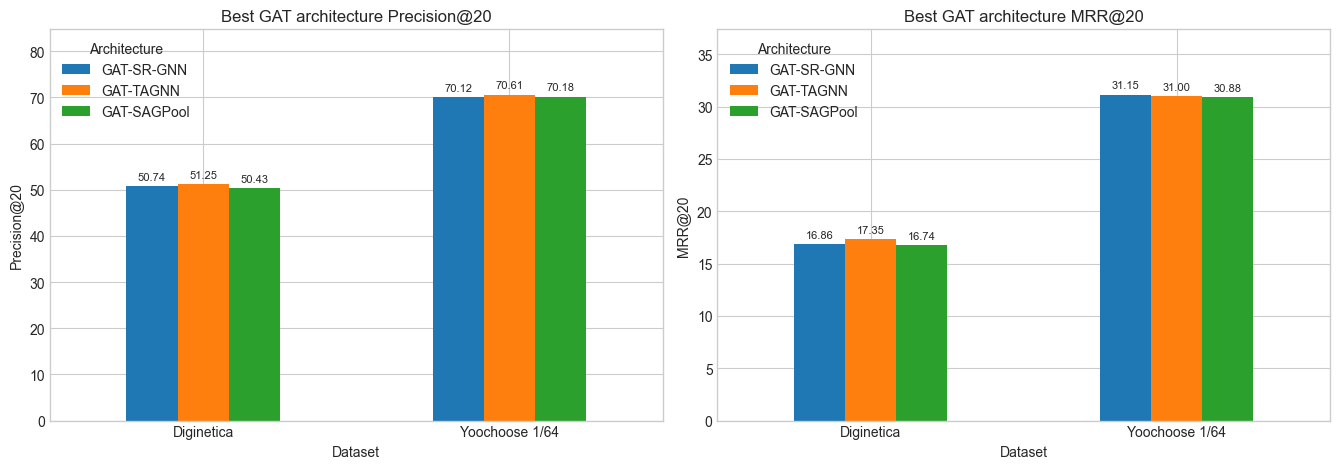

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, metric, ylabel in [
    (axes[0], "test_precision@20", "Precision@20"),
    (axes[1], "test_mrr@20", "MRR@20"),
]:
    pivot = best_vs_baseline.pivot(index="dataset", columns="model", values=metric)[[
        "GAT-SR-GNN",
        "GAT-TAGNN",
        "GAT-SAGPool",
    ]]
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"Best GAT architecture {ylabel}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel(ylabel)
    ax.legend(title="Architecture")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "architecture_best_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

In [40]:
evolution_rows = []
for model in ["GAT-SR-GNN", "GAT-TAGNN"]:
    datasets = sorted(all_runs.loc[all_runs["model"] == model, "dataset"].unique())
    for dataset in datasets:
        existing = all_runs[(all_runs["model"] == model) & (all_runs["dataset"] == dataset)].set_index("iteration")
        for run in ITERATIONS:
            iteration = run["iteration"]
            if iteration in existing.index:
                record = existing.loc[iteration].to_dict()
                record.update({"model": model, "dataset": dataset, "iteration": int(iteration), "folder": run["folder"], "status": "trained"})
            else:
                record = {column: pd.NA for column in EXPECTED_RESULT_COLUMNS}
                record.update({"model": model, "dataset": dataset, "iteration": int(iteration), "folder": run["folder"], "checkpoint_path": "pending rerun", "status": "pending"})
            evolution_rows.append(record)

model_evolution = (
    pd.DataFrame(evolution_rows)
    .sort_values(["model", "dataset", "iteration"])
    .reset_index(drop=True)
)
model_evolution.to_csv(PRESENTATION_DIR / "model_evolution.csv", index=False)
model_evolution

,model,folder,dataset,test_precision@20,test_mrr@20,test_loss,best_epoch,best_validation_precision@20,best_validation_mrr@20,train_examples,validation_examples,test_examples,num_items,checkpoint_path,iteration,status
0,GAT-SR-GNN,results-1,Diginetica,50.250,16.646,5.553,4,55.795,19.413,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,1,trained
1,GAT-SR-GNN,results-2,Diginetica,50.629,16.725,5.657,28,55.207,19.486,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,2,trained
2,GAT-SR-GNN,results-3,Diginetica,50.736,16.855,5.654,19,55.478,19.563,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,3,trained
3,GAT-SR-GNN,results-4,Diginetica,50.454,16.802,5.664,19,55.243,19.529,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_sr_gnn...,4,trained
4,GAT-SR-GNN,results-1,Yoochoose 1/64,70.124,31.146,4.342,9,69.474,32.706,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,1,trained
5,GAT-SR-GNN,results-2,Yoochoose 1/64,68.729,30.355,4.455,29,66.873,31.680,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,2,trained
6,GAT-SR-GNN,results-3,Yoochoose 1/64,68.942,30.563,4.451,25,66.903,31.759,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,3,trained
7,GAT-SR-GNN,results-4,Yoochoose 1/64,68.754,30.595,4.455,27,66.754,31.767,332874,36985,55898,37484,/kaggle/working/results/checkpoints/gat_sr_gnn...,4,trained
8,GAT-TAGNN,results-1,Diginetica,51.252,17.353,5.522,4,55.749,19.651,647523,71947,60858,43098,/kaggle/working/results/checkpoints/gat_tagnn_...,1,trained
9,GAT-TAGNN,results-2,Diginetica,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending rerun,2,pending


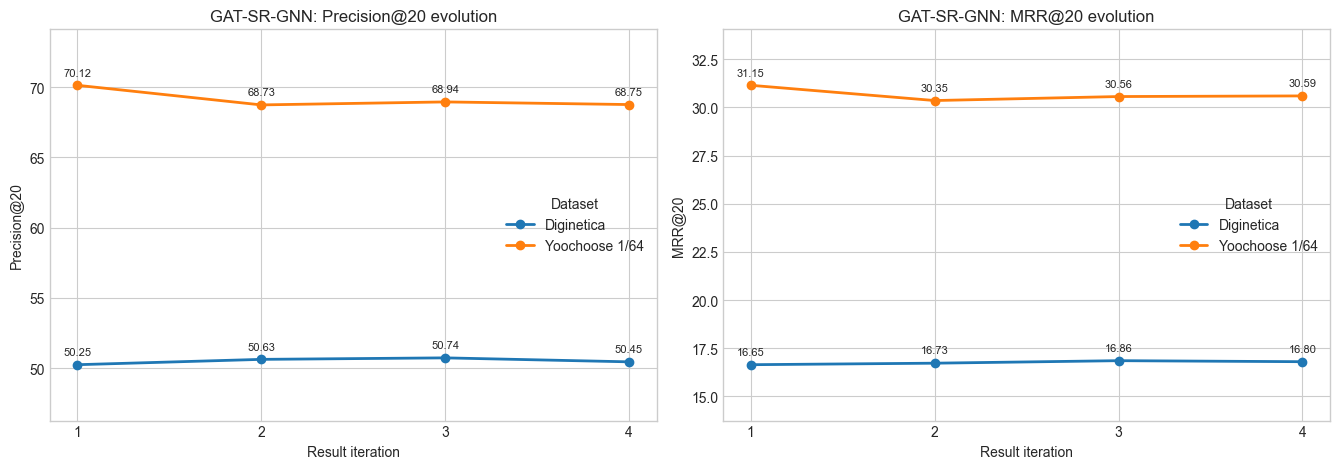

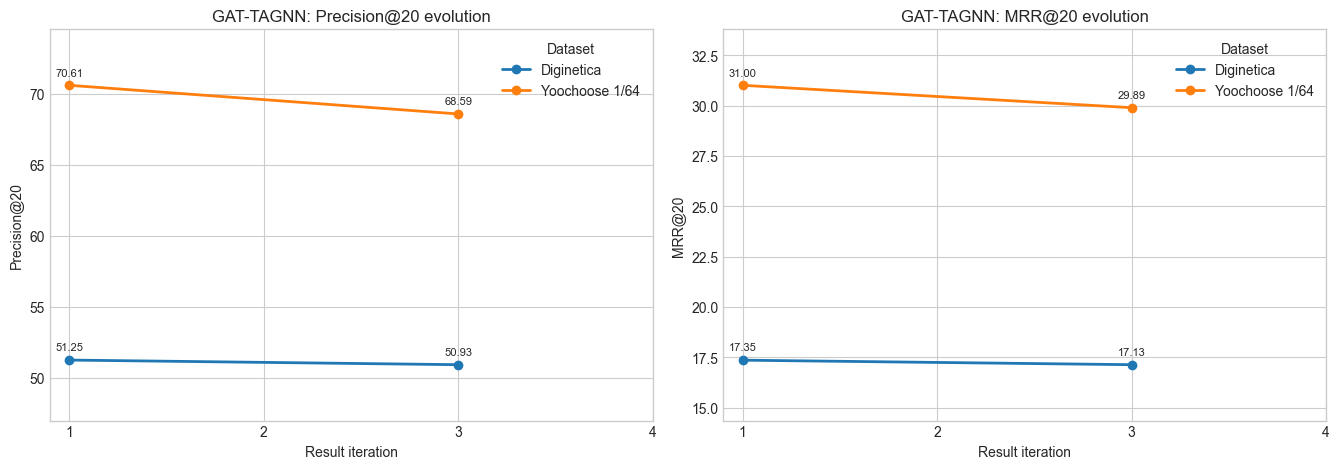

In [41]:
def plot_evolution(model, filename):
    model_runs = model_evolution[(model_evolution["model"] == model) & (model_evolution["status"] == "trained")].copy()
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=True)
    for ax, metric, ylabel in [(axes[0], "test_precision@20", "Precision@20"), (axes[1], "test_mrr@20", "MRR@20")]:
        for dataset, dataset_runs in model_runs.groupby("dataset"):
            dataset_runs = dataset_runs.sort_values("iteration")
            ax.plot(dataset_runs["iteration"], dataset_runs[metric], marker="o", linewidth=2, label=dataset)
            for _, row in dataset_runs.iterrows():
                ax.annotate(f"{row[metric]:.2f}", (row["iteration"], row[metric]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xlabel("Result iteration")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{model}: {ylabel} evolution")
        ax.legend(title="Dataset")
        ax.margins(y=0.2)
    fig.tight_layout()
    fig.savefig(PRESENTATION_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_evolution("GAT-SR-GNN", "gat_sr_gnn_evolution.png")
plot_evolution("GAT-TAGNN", "gat_tagnn_evolution.png")

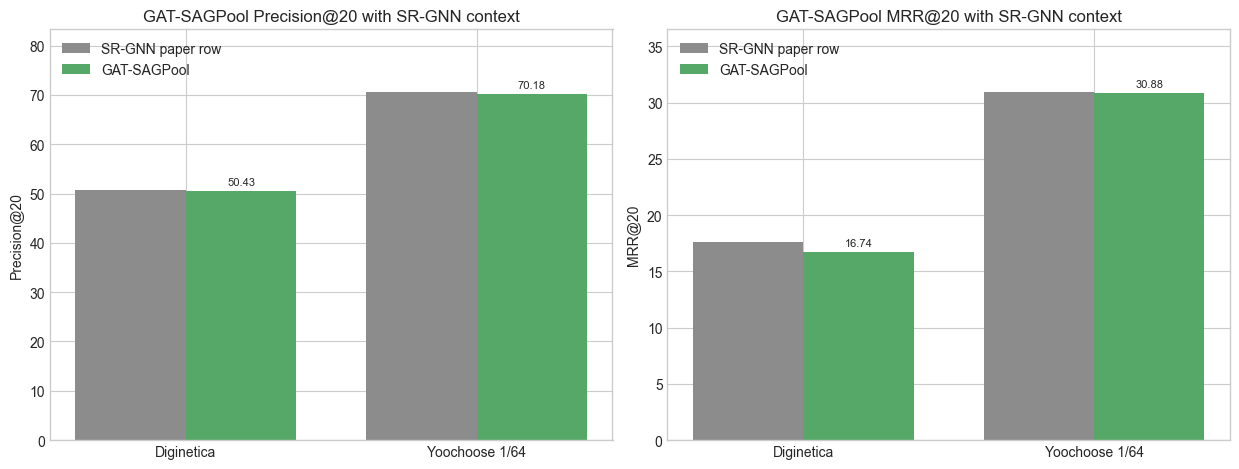

In [42]:
sagpool_context = best_vs_baseline[best_vs_baseline["model"] == "GAT-SAGPool"].copy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for ax, metric, reference_metric, ylabel in [
    (axes[0], "test_precision@20", "reference_precision@20", "Precision@20"),
    (axes[1], "test_mrr@20", "reference_mrr@20", "MRR@20"),
]:
    x_positions = list(range(len(sagpool_context)))
    width = 0.38
    ax.bar([x - width / 2 for x in x_positions], sagpool_context[reference_metric], width=width, label="SR-GNN paper row", color="#8c8c8c")
    bars = ax.bar([x + width / 2 for x in x_positions], sagpool_context[metric], width=width, label="GAT-SAGPool", color="#55a868")
    ax.set_xticks(x_positions, sagpool_context["dataset"])
    ax.set_title(f"GAT-SAGPool {ylabel} with SR-GNN context")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.18)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "gat_sagpool_baseline_context.png", dpi=180, bbox_inches="tight")
plt.show()

In [43]:
history_frames = []
for run in ITERATIONS:
    for filename, model in [("gat_sr_gnn_history.csv", "GAT-SR-GNN"), ("gat_tagnn_history.csv", "GAT-TAGNN")]:
        path = PROJECT_ROOT / run["folder"] / filename
        if path.is_file():
            history_frames.append(pd.read_csv(path).assign(model=model, iteration=int(run["iteration"]), folder=run["folder"]))

sagpool_history_path = PROJECT_ROOT / "results-gat-sagpool" / "gat_sagpool_history.csv"
if sagpool_history_path.is_file():
    history_frames.append(pd.read_csv(sagpool_history_path).assign(model="GAT-SAGPool", iteration=1, folder="results-gat-sagpool"))

training_histories = pd.concat(history_frames, ignore_index=True)
training_histories.to_csv(PRESENTATION_DIR / "training_histories.csv", index=False)
training_histories.head()

,dataset,epoch,train_loss,validation_loss,validation_precision@20,validation_mrr@20,epoch_seconds,train_examples,validation_examples,test_examples,model,iteration,folder,learning_rate
0,Yoochoose 1/64,1,5.527,4.725,64.664,28.646,153.680,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
1,Yoochoose 1/64,2,4.456,4.514,67.460,30.068,148.083,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
2,Yoochoose 1/64,3,4.202,4.443,68.468,30.689,147.950,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
3,Yoochoose 1/64,4,3.773,4.346,69.636,32.411,149.080,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN
4,Yoochoose 1/64,5,3.680,4.354,69.580,32.568,148.789,332874,36985,55898,GAT-SR-GNN,1,results-1,NaN


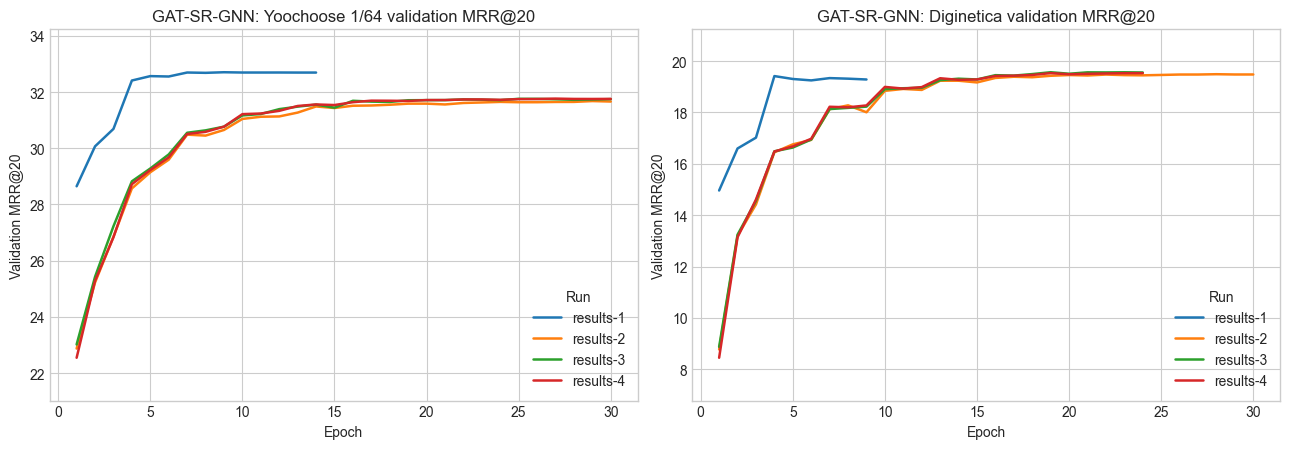

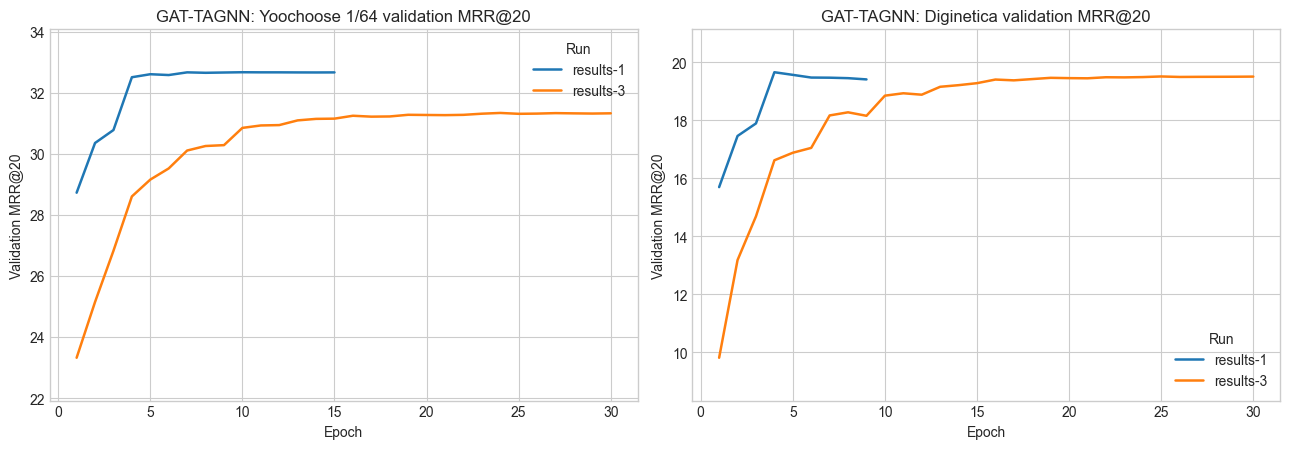

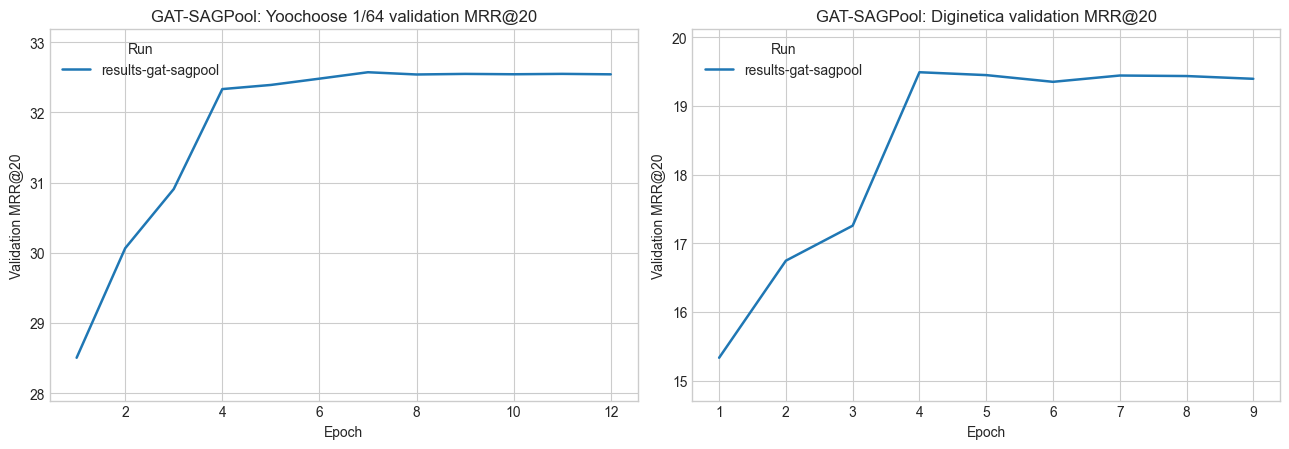

In [44]:
def plot_validation_history(model, filename):
    model_history = training_histories[training_histories["model"] == model].copy()
    datasets = list(model_history["dataset"].drop_duplicates())
    fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 4.6), squeeze=False)
    for ax, dataset in zip(axes[0], datasets):
        dataset_history = model_history[model_history["dataset"] == dataset]
        for iteration, run_history in dataset_history.groupby("iteration"):
            run_history = run_history.sort_values("epoch")
            label = f"results-{iteration}" if model != "GAT-SAGPool" else "results-gat-sagpool"
            ax.plot(run_history["epoch"], run_history["validation_mrr@20"], label=label, linewidth=1.8)
        ax.set_title(f"{model}: {dataset} validation MRR@20")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation MRR@20")
        ax.legend(title="Run")
        ax.margins(y=0.15)
    fig.tight_layout()
    fig.savefig(PRESENTATION_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_validation_history("GAT-SR-GNN", "gat_sr_gnn_validation_history.png")
plot_validation_history("GAT-TAGNN", "gat_tagnn_validation_history.png")
plot_validation_history("GAT-SAGPool", "gat_sagpool_validation_history.png")

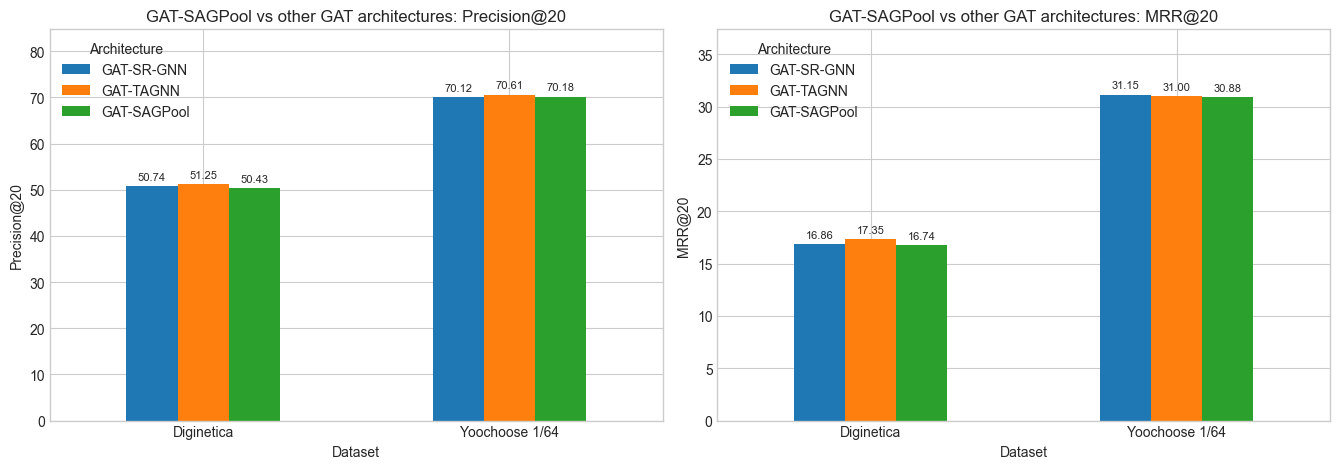

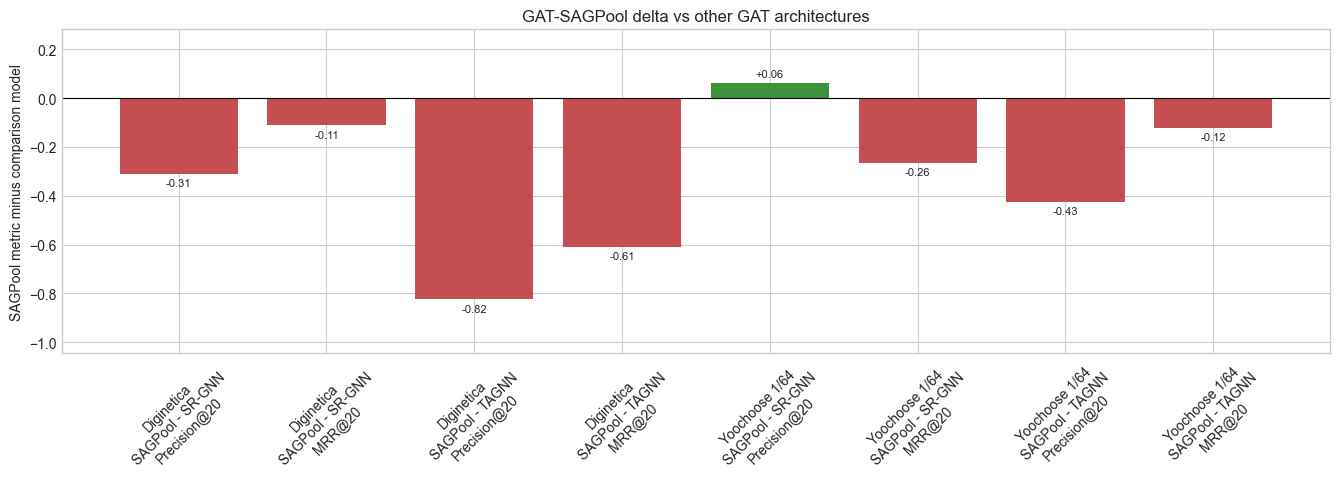

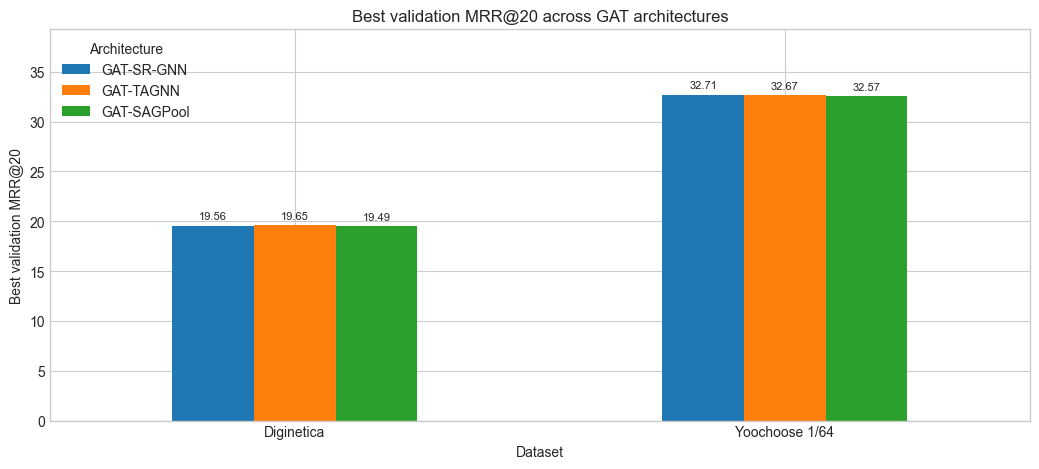

In [45]:
# Dedicated SAGPool comparison plots. These make the third architecture visible
# alongside the direct SR-GNN/TAGNN-readout branches instead of treating it as a footnote.
sagpool_comparison = best_vs_baseline.copy()
model_order = ["GAT-SR-GNN", "GAT-TAGNN", "GAT-SAGPool"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, metric, ylabel in [
    (axes[0], "test_precision@20", "Precision@20"),
    (axes[1], "test_mrr@20", "MRR@20"),
]:
    pivot = sagpool_comparison.pivot(index="dataset", columns="model", values=metric)[model_order]
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"GAT-SAGPool vs other GAT architectures: {ylabel}")
    ax.set_xlabel("Dataset")
    ax.set_ylabel(ylabel)
    ax.legend(title="Architecture")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "gat_sagpool_vs_architectures.png", dpi=180, bbox_inches="tight")
plt.show()

sagpool_deltas = []
for dataset in sorted(sagpool_comparison["dataset"].unique()):
    dataset_rows = sagpool_comparison[sagpool_comparison["dataset"] == dataset].set_index("model")
    sagpool_row = dataset_rows.loc["GAT-SAGPool"]
    for reference_model in ["GAT-SR-GNN", "GAT-TAGNN"]:
        reference_row = dataset_rows.loc[reference_model]
        for metric, label in [("test_precision@20", "Precision@20"), ("test_mrr@20", "MRR@20")]:
            sagpool_deltas.append({
                "dataset": dataset,
                "comparison": f"SAGPool - {reference_model.replace('GAT-', '')}",
                "metric": label,
                "delta": sagpool_row[metric] - reference_row[metric],
            })

sagpool_delta_df = pd.DataFrame(sagpool_deltas)
sagpool_delta_df.to_csv(PRESENTATION_DIR / "gat_sagpool_delta_vs_architectures.csv", index=False)
sagpool_delta_df["label"] = (
    sagpool_delta_df["dataset"]
    + "\n"
    + sagpool_delta_df["comparison"]
    + "\n"
    + sagpool_delta_df["metric"]
)
fig, ax = plt.subplots(figsize=(13.5, 5.0))
bars = ax.bar(
    sagpool_delta_df["label"],
    sagpool_delta_df["delta"],
    color=["#3a923a" if value >= 0 else "#c44e52" for value in sagpool_delta_df["delta"]],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("GAT-SAGPool delta vs other GAT architectures")
ax.set_ylabel("SAGPool metric minus comparison model")
ax.tick_params(axis="x", rotation=45)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
ax.margins(y=0.25)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "gat_sagpool_delta_vs_architectures.png", dpi=180, bbox_inches="tight")
plt.show()

validation_comparison = best_vs_baseline[[
    "model",
    "dataset",
    "best_validation_mrr@20",
]].copy()
fig, ax = plt.subplots(figsize=(10.5, 4.8))
validation_pivot = validation_comparison.pivot(
    index="dataset",
    columns="model",
    values="best_validation_mrr@20",
)[model_order]
validation_pivot.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Best validation MRR@20 across GAT architectures")
ax.set_xlabel("Dataset")
ax.set_ylabel("Best validation MRR@20")
ax.legend(title="Architecture")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "gat_sagpool_validation_vs_architectures.png", dpi=180, bbox_inches="tight")
plt.show()